Libraries:
- [pgmpy](https://pgmpy.org/index.html) -  biblioteka Pythona służąca do modelowania, uczenia i wnioskowania w probabilistycznych modelach graficznych, takich jak sieci Bayesowskie i sieci Markowa.

- pygraphviz

CausalForest robi:

Y_res = Y - E[Y|X]
T_res = T - E[T|X]

Jeśli:

T ≈ funkcja(X)

👉 T_res ≈ 0

👉 brak sygnału → singular matrix

In [221]:
import pandas as pd
from sklearn.model_selection import train_test_split

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination



In [222]:
df = pd.read_csv('../../data/processed/bank_data_preprocessed_v2.csv')


In [223]:
nominal_cols = ['job', 'marital']
df_processed = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

categorical_cols = ['default', 'housing', 'loan']
for col in categorical_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

df_processed.drop(columns=['month'], inplace=True)

In [224]:
if 'pdays_contacted' in df_processed.columns:
    df_processed['pdays_contacted'] = df_processed['pdays_contacted'].fillna(999)


In [225]:
X = df_processed.drop(['deposit', 'deposit_bin'], axis=1)
y = df_processed['deposit']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

X shape : (11162, 51)
y shape : (11162,)
Target distribution:
deposit
0    5873
1    5289
Name: count, dtype: int64


## Estymowanie indywidualnego efektu kampanii dla każdego klienta (CATE)

$$
τ(x) = E[Y | do(T=1), X=x] - E[Y | do(T=0), X=x]
$$

### a) treatment `campaign_capped`

In [226]:
# 0 = mała kampania
# 1 = duża kampania
T = (X['campaign_capped'] > 1).astype(int) # must be binary

In [227]:
# remove treatmenr from X
X = X.drop(columns=['campaign_capped'])

In [228]:
# ── 6.1  Train / Test Split ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(
    X, T, y,
    test_size=0.2,      # 80% train | 20% test
    random_state=42
)

print("Split Summary:")
print(f"  Train  → X: {X_train.shape}  |  y: {y_train.shape}")
print(f"  Test   → X: {X_test.shape}   |  y: {y_test.shape}")
print()
print("Class distribution after stratified split:")
print(f"  Train  yes={y_train.sum()} ({y_train.mean()*100:.1f}%)  "
      f"no={len(y_train)-y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")
print(f"  Test   yes={y_test.sum()} ({y_test.mean()*100:.1f}%)  "
      f"no={len(y_test)-y_test.sum()} ({(1-y_test.mean())*100:.1f}%)")

Split Summary:
  Train  → X: (8929, 50)  |  y: (8929,)
  Test   → X: (2233, 50)   |  y: (2233,)

Class distribution after stratified split:
  Train  yes=4222 (47.3%)  no=4707 (52.7%)
  Test   yes=1067 (47.8%)  no=1166 (52.2%)


In [229]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

model = CausalForestDML(
    model_y=RandomForestRegressor(),
    model_t=RandomForestRegressor(),
    discrete_treatment=True,
    n_estimators=100,
    min_samples_leaf=50,
    random_state=42
)

In [230]:
model.fit(
    y_train,
    T_train,
    X=X_train
)

c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)
c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)


In [231]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, T_train)

print("Predictability of T:", clf.score(X_test, T_test))


# | wynik    | znaczenie                            |
# | -------- | ------------------------------------ |
# | ~0.5–0.7 | OK                                   |
# | >0.9     | 💥 treatment przewidywalny → problem |


Predictability of T: 0.5969547693685625


In [232]:
treatment_effect = model.effect(X_test)

In [ ]:
ATE = treatment_effect.mean()
print("ATE:", ATE)

# 👉 efekt negatywny
# ➡️ zmniejsza prawdopodobieństwo depozytu o ~2.7 pp 
# czyli: 👉 kampania trafia do trudnych klientów

ATE: -0.027604499010237996


In [234]:
import numpy as np

print("Średni efekt:", np.mean(treatment_effect))
print("Min efekt:", np.min(treatment_effect))
print("Max efekt:", np.max(treatment_effect))

Średni efekt: -0.027604499010237996
Min efekt: -0.10105982571859294
Max efekt: 0.033777572377165


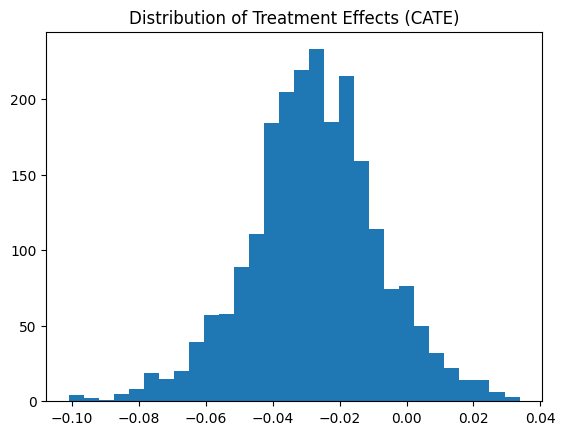

In [235]:
import matplotlib.pyplot as plt

plt.hist(treatment_effect, bins=30)
plt.title("Distribution of Treatment Effects (CATE)")
plt.show()

#### Feature importance

In [236]:
importances = model.feature_importances_

for name, val in zip(X.columns, importances):
    print(name, val)

age 0.13356718215217195
default 0.0
housing 0.005318402252781153
loan 0.0005557183998928836
duration 0.25600816251324976
pdays 0.039025624326659715
was_previously_contacted 1.3539833314525296e-05
pdays_contacted 0.06629112974336568
has_debt 0.005212962700333896
net_balance_indicator 0.0
financial_stress 0.005507163624068519
previous_log1p 0.011669347128885225
balance_log1p 0.1591488661248489
poutcome_is_unknown 0.0
contact_is_unknown 0.008862878553238375
poutcome_failure 0.003883142782526929
poutcome_other 0.00012950016703303728
poutcome_success 0.0016889851755210563
contact_cellular 0.014378432510454614
contact_telephone 0.0377466100476771
education_primary 0.002493068070761467
education_secondary 0.030641668268546633
education_tertiary 0.018354041401132806
education_unknown 0.0
is_peak_month 0.00882743910205797
month_apr 0.020741338656874983
month_aug 0.034184841119327895
month_dec 0.0
month_feb 0.031212480522391856
month_jan 0.0
month_jul 0.0043487380124562
month_jun 0.0210709487185

In [237]:
print("Treatment distribution:", T.mean()) # musi być ~0.2–0.8

Treatment distribution: 0.5701487188675864


In [238]:
print("ATE:", ATE)

ATE: -0.027604499010237996


In [239]:
np.std(treatment_effect) # czyli jak bardzo efekty różnią się między sobą (heterogeniczność) (od klienta)

### b) treatment `contact_cellular`

In [240]:
X = df_processed.drop(['deposit', 'deposit_bin'], axis=1)
y = df_processed['deposit']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

X shape : (11162, 51)
y shape : (11162,)
Target distribution:
deposit
0    5873
1    5289
Name: count, dtype: int64


In [241]:
# 0 = mała kampania
# 1 = duża kampania
T = X['contact_cellular'].astype(int)

In [242]:
# remove treatment from X
X = X.drop(columns=['contact_cellular'])

In [243]:
X = X.drop(columns=[
    'contact_is_unknown',
    'education_unknown',
    'job_unknown'
])

In [244]:
import numpy as np

corr = X.corr().abs()
high_corr = np.where(corr > 0.95)

# print highly correlated pairs
for i, j in zip(*high_corr):
    if i != j:
        print(X.columns[i], X.columns[j])

was_previously_contacted pdays_contacted
was_previously_contacted poutcome_is_unknown
pdays_contacted was_previously_contacted
pdays_contacted poutcome_is_unknown
poutcome_is_unknown was_previously_contacted
poutcome_is_unknown pdays_contacted


In [245]:
# ── 6.1  Train / Test Split ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(
    X, T, y,
    test_size=0.2,      # 80% train | 20% test
    random_state=42
)

print("Split Summary:")
print(f"  Train  → X: {X_train.shape}  |  y: {y_train.shape}")
print(f"  Test   → X: {X_test.shape}   |  y: {y_test.shape}")
print()
print("Class distribution after stratified split:")
print(f"  Train  yes={y_train.sum()} ({y_train.mean()*100:.1f}%)  "
      f"no={len(y_train)-y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")
print(f"  Test   yes={y_test.sum()} ({y_test.mean()*100:.1f}%)  "
      f"no={len(y_test)-y_test.sum()} ({(1-y_test.mean())*100:.1f}%)")

Split Summary:
  Train  → X: (8929, 47)  |  y: (8929,)
  Test   → X: (2233, 47)   |  y: (2233,)

Class distribution after stratified split:
  Train  yes=4222 (47.3%)  no=4707 (52.7%)
  Test   yes=1067 (47.8%)  no=1166 (52.2%)


In [246]:
print("T_train shape:", T_train.shape)
print("Unique values:", T_train.unique())

T_train shape: (8929,)
Unique values: [1 0]


In [247]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

model = CausalForestDML(
    model_y=RandomForestRegressor(),
    model_t=RandomForestRegressor(),
    discrete_treatment=True,
    n_estimators=100,
    min_samples_leaf=50,
    random_state=42
)

In [248]:
model.fit(
    y_train,
    T_train,
    X=X_train
)

c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)
c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)


In [249]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, T_train)

print("Predictability of T:", clf.score(X_test, T_test))


# | wynik    | znaczenie                            |
# | -------- | ------------------------------------ |
# | ~0.5–0.7 | OK                                   |
# | >0.9     | 💥 treatment przewidywalny → problem |


Predictability of T: 0.9243170622480967


In [ ]:
treatment_effect = model.effect(X_test)
ATE = treatment_effect.mean()
print("ATE:", ATE)

# 👉 efekt pozytywny (umiarkowany)
# ➡️ +18 pp konwersji
# czyli: 👉 kanał kontaktu ma duży wpływ

ATE: 0.18074531600530758


In [251]:
import numpy as np

print("Średni efekt:", np.mean(treatment_effect))
print("Min efekt:", np.min(treatment_effect))
print("Max efekt:", np.max(treatment_effect))

Średni efekt: 0.18074531600530758
Min efekt: -0.45142086536004156
Max efekt: 0.6673497429627643


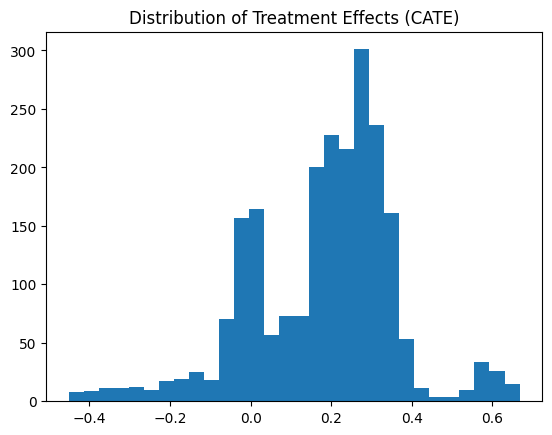

In [252]:
import matplotlib.pyplot as plt

plt.hist(treatment_effect, bins=30)
plt.title("Distribution of Treatment Effects (CATE)")
plt.show()

#### Feature importance

In [253]:
importances = model.feature_importances_

for name, val in zip(X.columns, importances):
    print(name, val)

age 0.016166201737931003
default 0.0
housing 0.003371027165629447
loan 7.426423789668355e-05
duration 0.46307932286777814
pdays 0.045745047348079354
was_previously_contacted 0.0
pdays_contacted 0.0534133849491006
has_debt 0.012193888267676424
net_balance_indicator 0.0
financial_stress 0.0001460661471069687
previous_log1p 0.013861685523395331
balance_log1p 0.021941162030076473
campaign_capped 0.0058462119750003995
poutcome_is_unknown 0.002556945737254105
poutcome_failure 0.008541569473151654
poutcome_other 0.0
poutcome_success 7.334715539928292e-05
contact_telephone 0.0
education_primary 0.0009113658430603892
education_secondary 0.0026320596376265756
education_tertiary 0.0005171613839193555
is_peak_month 0.0024430763499300803
month_apr 0.009301626414370942
month_aug 0.0191767187516554
month_dec 0.0
month_feb 0.011061202649582649
month_jan 0.0
month_jul 0.00015100751641915322
month_jun 0.2095502076680543
month_mar 0.0
month_may 0.009189111081761092
month_nov 0.08023812610602674
month_oct

In [254]:
print("Treatment distribution:", T.mean()) # musi być ~0.2–0.8

Treatment distribution: 0.7204802006808816


In [255]:
print("ATE:", ATE)

ATE: 0.18074531600530758


In [256]:
np.std(treatment_effect) # czyli jak bardzo efekty różnią się między sobą (heterogeniczność) (od klienta)

### c) treatment `was_previously_contacted`

In [257]:
X = df_processed.drop(['deposit', 'deposit_bin'], axis=1)
y = df_processed['deposit']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

X shape : (11162, 51)
y shape : (11162,)
Target distribution:
deposit
0    5873
1    5289
Name: count, dtype: int64


In [258]:
# 0 = mała kampania
# 1 = duża kampania
T = X['was_previously_contacted'].astype(int) # must be binary

# remove treatment from X
X = X.drop(columns=['was_previously_contacted'])

In [259]:
# PERFECT MULTICOLLINEARITY (OHE)
# razemz awsze 1 dają 1, więc usuwamy te kolumny, które są redundantne (nie wnoszą dodatkowej informacji)
X = X.drop(columns=[
    'contact_is_unknown',
    'education_unknown',
    'job_unknown'
])

In [260]:
import numpy as np

corr = X.corr().abs()
high_corr = np.where(corr > 0.95)

# print highly correlated pairs
for i, j in zip(*high_corr):
    if i != j:
        print(X.columns[i], X.columns[j])

pdays_contacted poutcome_is_unknown
poutcome_is_unknown pdays_contacted


In [261]:
# ── 6.1  Train / Test Split ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(
    X, T, y,
    test_size=0.2,      # 80% train | 20% test
    random_state=42
)

print("Split Summary:")
print(f"  Train  → X: {X_train.shape}  |  y: {y_train.shape}")
print(f"  Test   → X: {X_test.shape}   |  y: {y_test.shape}")
print()
print("Class distribution after stratified split:")
print(f"  Train  yes={y_train.sum()} ({y_train.mean()*100:.1f}%)  "
      f"no={len(y_train)-y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")
print(f"  Test   yes={y_test.sum()} ({y_test.mean()*100:.1f}%)  "
      f"no={len(y_test)-y_test.sum()} ({(1-y_test.mean())*100:.1f}%)")

Split Summary:
  Train  → X: (8929, 47)  |  y: (8929,)
  Test   → X: (2233, 47)   |  y: (2233,)

Class distribution after stratified split:
  Train  yes=4222 (47.3%)  no=4707 (52.7%)
  Test   yes=1067 (47.8%)  no=1166 (52.2%)


In [262]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

model = CausalForestDML(
    model_y=RandomForestRegressor(),
    model_t=RandomForestRegressor(),
    discrete_treatment=True,
    n_estimators=100,
    min_samples_leaf=50,
    random_state=42
)

In [263]:
model.fit(
    y_train,
    T_train,
    X=X_train
)

c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)
c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)


In [264]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, T_train)

print("Predictability of T:", clf.score(X_test, T_test))


# | wynik    | znaczenie                            |
# | -------- | ------------------------------------ |
# | ~0.5–0.7 | OK                                   |
# | >0.9     | 💥 treatment przewidywalny → problem |


Predictability of T: 1.0


In [ ]:
treatment_effect = model.effect(X_test)
ATE = treatment_effect.mean()
print("ATE:", ATE)

# mało relane (post - treatment?)

ATE: 0.9374380399830953


In [266]:
import numpy as np

print("Średni efekt:", np.mean(treatment_effect))
print("Min efekt:", np.min(treatment_effect))
print("Max efekt:", np.max(treatment_effect))

Średni efekt: 0.9374380399830953
Min efekt: 0.0
Max efekt: 2.4522908769934344


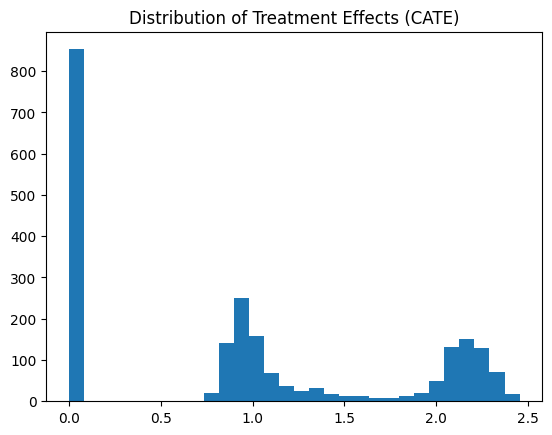

In [267]:
import matplotlib.pyplot as plt

plt.hist(treatment_effect, bins=30)
plt.title("Distribution of Treatment Effects (CATE)")
plt.show()

#### Feature importance

In [268]:
importances = model.feature_importances_

for name, val in zip(X.columns, importances):
    print(name, val)

age 0.03514884859190679
default 0.0
housing 0.030004501424917795
loan 0.02657011238248902
duration 0.23531213927325165
pdays 0.03664646439950738
pdays_contacted 0.014752866849683076
has_debt 0.017503401617031088
net_balance_indicator 0.003182060461176933
financial_stress 0.006389040145293921
previous_log1p 0.027892700461288267
balance_log1p 0.01962831536882744
campaign_capped 0.07636056141980986
poutcome_is_unknown 0.021982211524669944
poutcome_failure 0.021613714899154715
poutcome_other 0.00036541775786022557
poutcome_success 0.020678030417563092
contact_cellular 0.001649764460277783
contact_telephone 0.0038144034568862034
education_primary 0.017747135307766126
education_secondary 0.05127819087255707
education_tertiary 0.03849028429386629
is_peak_month 0.04353715895712951
month_apr 0.002564781056743097
month_aug 0.02070698513280643
month_dec 0.0
month_feb 0.006391962030256069
month_jan 0.0
month_jul 0.02300097894220845
month_jun 0.005686898286203394
month_mar 0.0
month_may 0.016093982

In [269]:
print("Treatment distribution:", T.mean()) # musi być ~0.2–0.8

Treatment distribution: 0.25425550976527506


In [270]:
print("ATE:", ATE)

ATE: 0.9374380399830953


In [271]:
np.std(treatment_effect) # czyli jak bardzo efekty różnią się między sobą (heterogeniczność) (od klienta)

-----------------------

In [273]:
results = {}

for treatment in ['campaign_capped', 'contact_cellular']:
    T = df_processed[treatment].astype(int)
    X_tmp = df_processed.drop(columns=[treatment, 'deposit', 'deposit_bin'])

    model.fit(y, T, X=X_tmp)
    ate = model.effect(X_tmp).mean()

    results[treatment] = ate

print(results)

c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)


ValueError: cannot reshape array of size 5581 into shape (5581,12)

## WNIOSKI

### 📌 1. Campaign intensity

> Increasing campaign intensity does not improve conversion probability and may even have a slightly negative effect, likely due to targeting bias.

---

### 📌 2. Communication channel

> The communication channel exhibits a substantial positive effect on customer response.

---

### 📌 3. Customer history

> Variables related to prior interactions show extremely strong predictive power, but should not be interpreted causally.

---

### 📌 4. Model comparison

> Results from Bayesian Networks and Causal Forest are consistent in terms of the direction of the campaign effect.
